# 📉 Customer Churn Prediction
### Binary Classification | EDA | Class Imbalance | SMOTE | Threshold Tuning | SHAP

---
 
**Dataset:** Telco Customer Churn (IBM / Kaggle)  
**Goal:** Predict which customers are likely to churn so the business can intervene proactively

**Best Model: Random Forest | CV F1: 0.8567 | ROC-AUC: 0.9256**

---

### Table of Contents
1. [Imports & Data Loading](#1)
2. [Data Overview & Cleaning](#2)
3. [Exploratory Data Analysis](#3)
4. [Preprocessing](#4)
5. [Model Comparison](#5)
6. [Threshold Tuning](#6)
7. [Hyperparameter Tuning](#7)
8. [Final Evaluation](#8)
9. [Feature Importance](#9)
10. [Conclusion](#10)


<a id='1'></a>
## 1. Imports & Data Loading

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

SEED = 42

In [28]:
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<a id='2'></a>
## 2. Data Overview & Cleaning

In [29]:
print('--- Basic Info ---')
print(f'Rows       : {df.shape[0]}')
print(f'Columns    : {df.shape[1]}')
print(f'Duplicates : {df.duplicated().sum()}')
print()
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print('Target distribution:')
print(df['Churn'].value_counts())
print(f'\nChurn rate: {df["Churn"].value_counts(normalize=True)["Yes"]*100:.1f}%')

--- Basic Info ---
Rows       : 7043
Columns    : 21
Duplicates : 0

Missing values per column:
Series([], dtype: int64)

Target distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


In [30]:
# Drop customerID — not a feature
df = df.drop(columns=['customerID'],axis=1)

# TotalCharges is stored as string — blank strings are missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'TotalCharges NaNs after coerce: {df["TotalCharges"].isnull().sum()}')

# These 11 rows have tenure=0 (new customers, no charges yet) — fill with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Encode target: Yes -> 1, No -> 0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print(f'\nShape after cleaning: {df.shape}')
print(f'Missing values remaining: {df.isnull().sum().sum()}')

TotalCharges NaNs after coerce: 11

Shape after cleaning: (7043, 20)
Missing values remaining: 0


In [31]:
# Data types overview
print('Numerical columns:')
print([c for c in df.columns if df[c].dtype != 'object'])
print()
print('Categorical columns:')
print([c for c in df.columns if df[c].dtype == 'object'])
print()
df.describe().T.round(2)

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']



,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.16,0.37,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.73,2266.79,0.00,398.55,1394.55,3786.60,8684.80
Churn,7043.0,0.27,0.44,0.00,0.00,0.00,1.00,1.00


<a id='3'></a>
## 3. Exploratory Data Analysis

### 3.1 Churn Rate

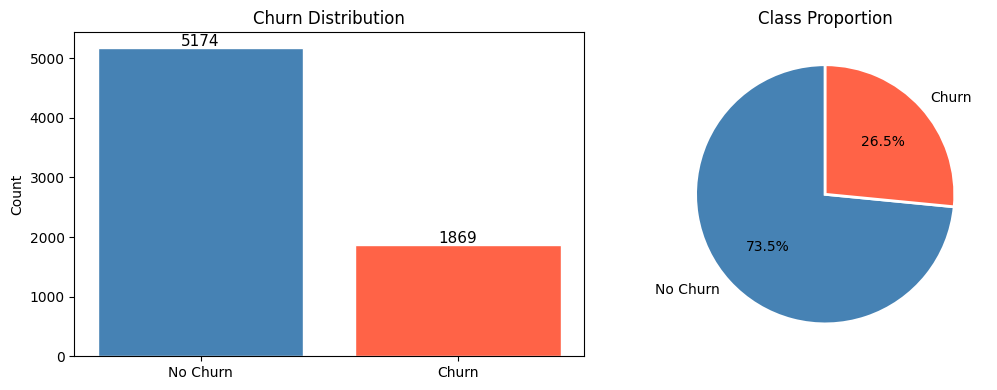

Dataset is imbalanced (~26% churn) — class imbalance handling required.


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df['Churn'].value_counts()
labels = ['No Churn', 'Churn']
axes[0].bar(labels, counts.values, color=['steelblue', 'tomato'], edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=11)
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=labels,
            colors=['steelblue', 'tomato'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.show()
print('Dataset is imbalanced (~26% churn) — class imbalance handling required.')

**Observation:** The dataset is imbalanced with only ~26% churn. Accuracy alone will be misleading — we must focus on **F1-score** and **ROC-AUC** for the churn class, and apply **SMOTE** during preprocessing.

### 3.2 Churn by Key Categorical Features

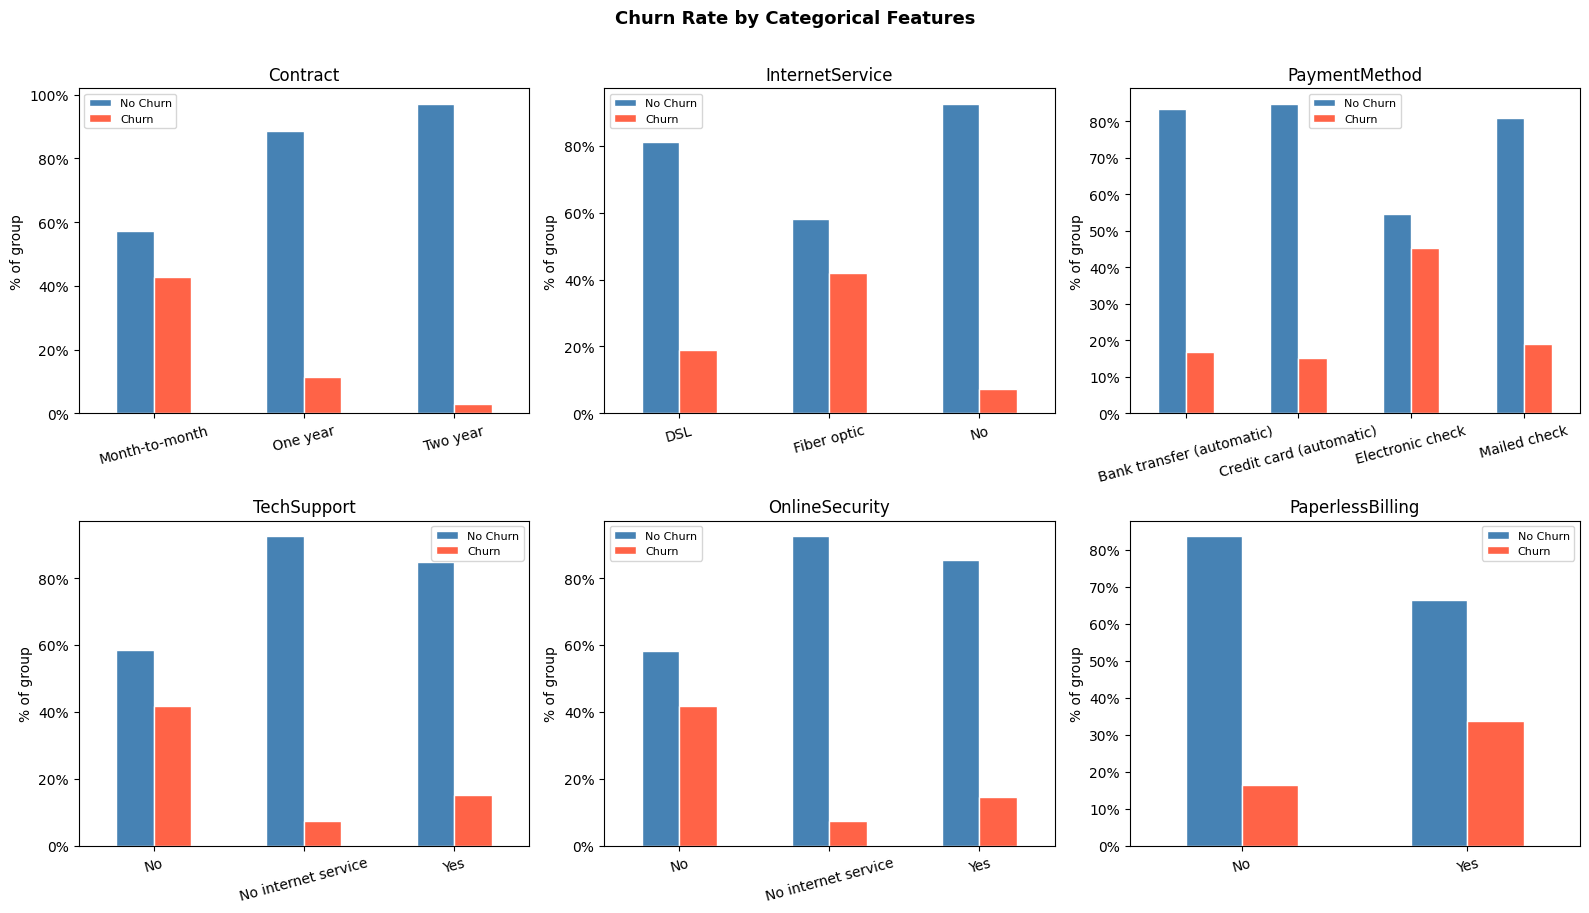

In [33]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod',
            'TechSupport', 'OnlineSecurity', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = df.groupby([col, 'Churn']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=axes[i],
                color=['steelblue', 'tomato'],
                edgecolor='white', rot=15)
    axes[i].set_title(col)
    axes[i].set_ylabel('% of group')
    axes[i].set_xlabel('')
    axes[i].legend(['No Churn', 'Churn'], fontsize=8)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.suptitle('Churn Rate by Categorical Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observations:**
- **Contract type** is the strongest signal — month-to-month customers churn at ~42%, vs ~3% for two-year contracts
- **No OnlineSecurity / TechSupport** dramatically increases churn — customers without these add-ons feel less locked in
- **Electronic check** payment method has the highest churn among payment types
- **Fiber optic** internet users churn more than DSL users — possibly due to higher monthly costs


### 3.3 Churn by Numerical Features

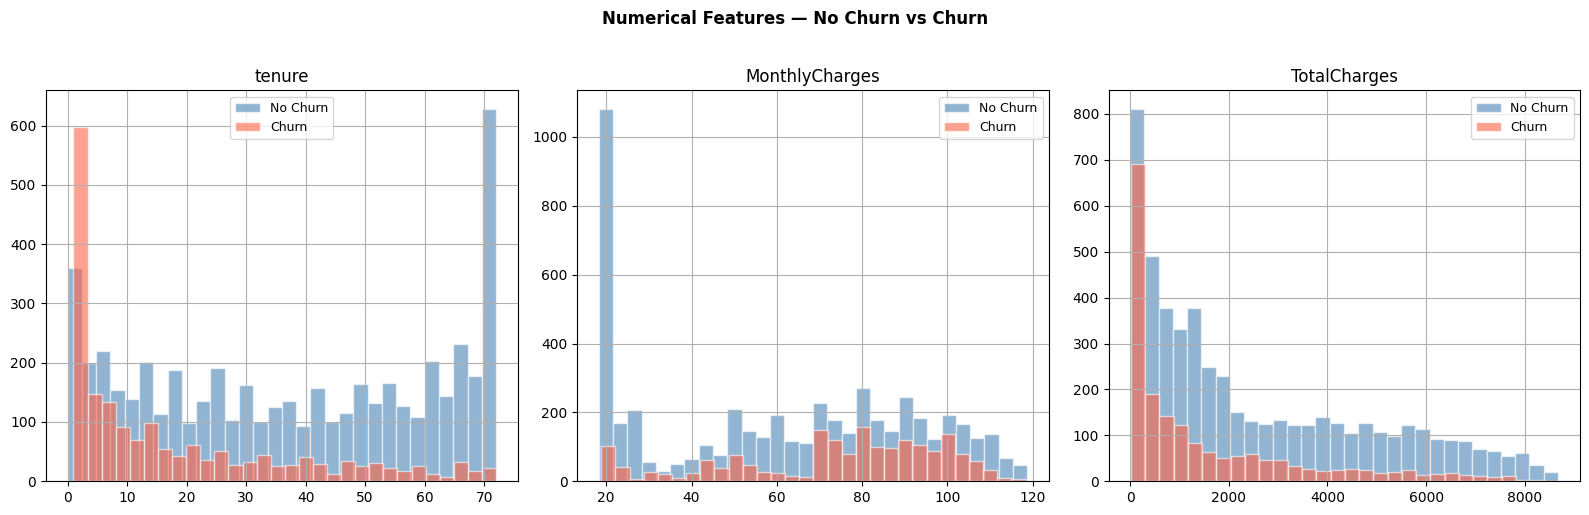

In [34]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_cols):
    df[df['Churn']==0][col].hist(ax=axes[i], bins=30, alpha=0.6,
                                  color='steelblue', label='No Churn', edgecolor='white')
    df[df['Churn']==1][col].hist(ax=axes[i], bins=30, alpha=0.6,
                                  color='tomato', label='Churn', edgecolor='white')
    axes[i].set_title(col)
    axes[i].legend(fontsize=9)

plt.suptitle('Numerical Features — No Churn vs Churn',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- **Tenure:** Churners are heavily concentrated in the first 1–12 months. Long-tenure customers almost never churn — early retention is critical
- **MonthlyCharges:** Churners tend to have higher monthly charges — price sensitivity is a major driver
- **TotalCharges:** Lower total charges for churners — consistent with short tenure


### 3.4 Correlation Heatmap

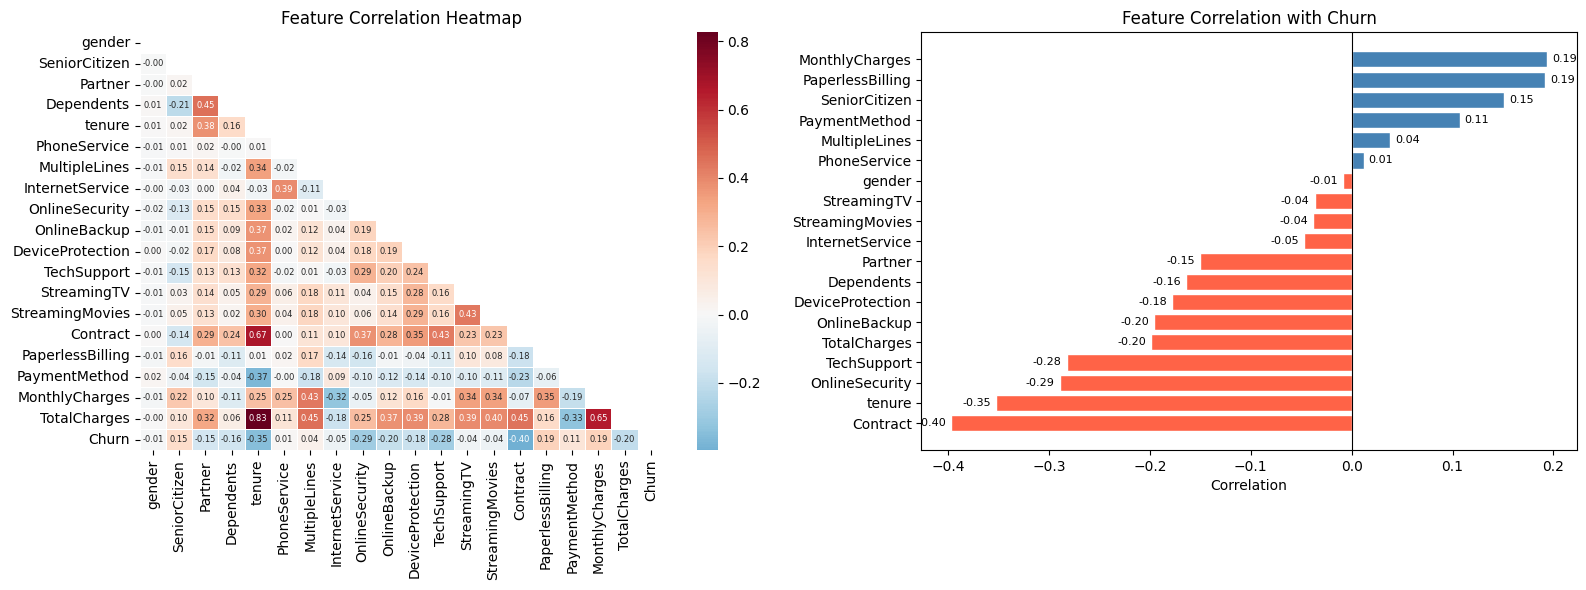

Top 3 features correlated with churn:
  Contract: -0.397
  tenure: -0.352
  OnlineSecurity: -0.289


In [35]:
# Encode categoricals temporarily for correlation
df_corr = df.copy()
for col in df_corr.select_dtypes('object').columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.4,
            ax=axes[0], annot_kws={'size': 6})
axes[0].set_title('Feature Correlation Heatmap')

target_corr = corr['Churn'].drop('Churn').sort_values()
colors = ['tomato' if v < 0 else 'steelblue' for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
for i, v in enumerate(target_corr.values):
    axes[1].text(v + (0.005 if v >= 0 else -0.005), i,
                 f'{v:.2f}', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=8)
axes[1].set_title('Feature Correlation with Churn')
axes[1].set_xlabel('Correlation')

plt.tight_layout()
plt.show()

top3 = target_corr.abs().sort_values(ascending=False).head(3)
print('Top 3 features correlated with churn:')
for feat, _ in top3.items():
    print(f'  {feat}: {target_corr[feat]:.3f}')

<a id='4'></a>
## 4. Preprocessing

In [36]:
# One-hot encode all categorical columns (drop_first avoids multicollinearity)
df_model = pd.get_dummies(df, drop_first=True)

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

print(f'Features after encoding: {X.shape[1]}')
print(f'Target distribution:\n{y.value_counts()}')

Features after encoding: 30
Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [37]:
# Split first — SMOTE applied only on training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Apply SMOTE on training data only to fix class imbalance
# SMOTE generates synthetic minority-class (churn) samples
smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print(f'Train (original) : {y_train.value_counts().to_dict()}')
print(f'Train (after SMOTE): {pd.Series(y_train_sm).value_counts().to_dict()}')
print(f'Test             : {y_test.value_counts().to_dict()}')
print()
print('Note: SMOTE applied only on training data — test set remains real distribution.')

Train (original) : {0: 4139, 1: 1495}
Train (after SMOTE): {0: 4139, 1: 4139}
Test             : {0: 1035, 1: 374}

Note: SMOTE applied only on training data — test set remains real distribution.


<a id='5'></a>
## 5. Model Comparison

Comparing 4 models using **stratified 5-fold cross-validation** on the SMOTE-balanced training set.
We track **F1-score (churn class)** as the primary metric — more meaningful than accuracy for imbalanced data.


In [38]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=SEED),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=SEED),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    'XGBoost'             : XGBClassifier(n_estimators=200, random_state=SEED,
                                          eval_metric='logloss', verbosity=0),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []

print(f'{"Model":<25} | {"CV F1 (mean)":>14} | {"CV F1 (std)":>12} | {"ROC-AUC":>10}')
print('-' * 70)

for name, model in models.items():
    f1_scores  = cross_val_score(model, X_train_sm, y_train_sm,
                                  cv=cv, scoring='f1')
    auc_scores = cross_val_score(model, X_train_sm, y_train_sm,
                                  cv=cv, scoring='roc_auc')
    results.append({
        'Model'       : name,
        'CV F1 Mean'  : f1_scores.mean(),
        'CV F1 Std'   : f1_scores.std(),
        'CV AUC Mean' : auc_scores.mean()
    })
    print(f'{name:<25} | {f1_scores.mean():>14.4f} | {f1_scores.std():>12.4f} | {auc_scores.mean():>10.4f}')

results_df = pd.DataFrame(results).sort_values('CV F1 Mean', ascending=False)
print('\nBest model:', results_df.iloc[0]['Model'])

Model                     |   CV F1 (mean) |  CV F1 (std) |    ROC-AUC
----------------------------------------------------------------------
Logistic Regression       |         0.7830 |       0.0063 |     0.8549
Random Forest             |         0.8567 |       0.0061 |     0.9256
Gradient Boosting         |         0.8517 |       0.0114 |     0.9324
XGBoost                   |         0.8484 |       0.0035 |     0.9297

Best model: Random Forest


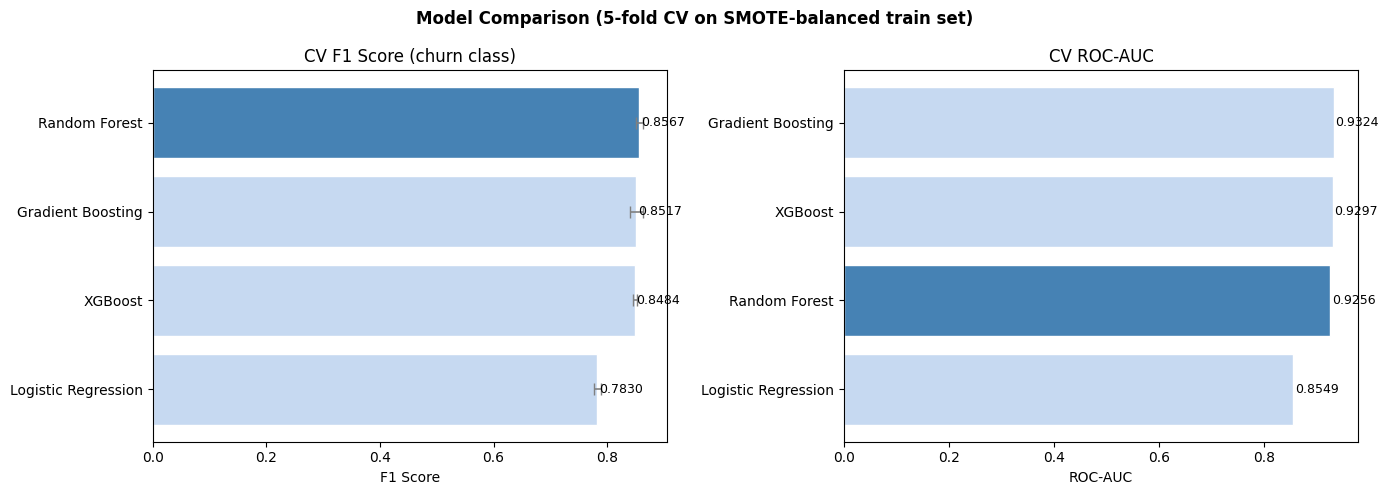

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 comparison
r = results_df.sort_values('CV F1 Mean')
bar_colors = ['steelblue' if n == results_df.iloc[0]['Model'] else '#c6d9f1'
              for n in r['Model']]
bars = axes[0].barh(r['Model'], r['CV F1 Mean'], color=bar_colors, edgecolor='white')
axes[0].errorbar(r['CV F1 Mean'], r['Model'], xerr=r['CV F1 Std'],
                  fmt='none', color='gray', capsize=4, linewidth=1.2)
for bar, val in zip(bars, r['CV F1 Mean']):
    axes[0].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)
axes[0].set_title('CV F1 Score (churn class)')
axes[0].set_xlabel('F1 Score')

# AUC comparison
r2 = results_df.sort_values('CV AUC Mean')
bar_colors2 = ['steelblue' if n == results_df.iloc[0]['Model'] else '#c6d9f1'
               for n in r2['Model']]
bars2 = axes[1].barh(r2['Model'], r2['CV AUC Mean'], color=bar_colors2, edgecolor='white')
for bar, val in zip(bars2, r2['CV AUC Mean']):
    axes[1].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)
axes[1].set_title('CV ROC-AUC')
axes[1].set_xlabel('ROC-AUC')

plt.suptitle('Model Comparison (5-fold CV on SMOTE-balanced train set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='6'></a>
## 6. Threshold Tuning

The default classification threshold (0.5) is not optimal for imbalanced datasets.
We use the **Precision-Recall curve** to find the threshold that maximizes F1 for the churn class.

This matters in a business context: missing a churner (false negative) costs more
than unnecessarily retaining a loyal customer (false positive).


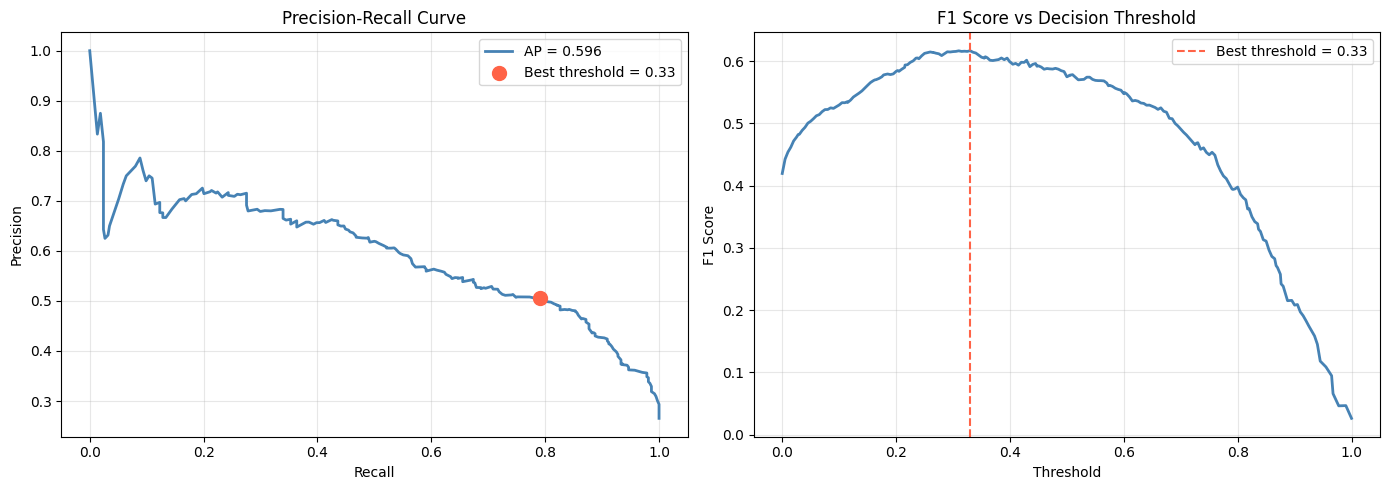

Optimal threshold: 0.3300  (default was 0.5)


In [40]:
best_model_name = results_df.iloc[0]['Model']
best_model_base  = models[best_model_name]

# Fit on full SMOTE training set
best_model_base.fit(X_train_sm, y_train_sm)
y_prob = best_model_base.predict_proba(X_test_sc)[:, 1]

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores_thresh = 2 * precision * recall / (precision + recall + 1e-9)
best_thresh_idx  = np.argmax(f1_scores_thresh)
best_threshold   = thresholds[best_thresh_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve
ap = average_precision_score(y_test, y_prob)
axes[0].plot(recall, precision, color='steelblue', linewidth=2,
             label=f'AP = {ap:.3f}')
axes[0].scatter(recall[best_thresh_idx], precision[best_thresh_idx],
                color='tomato', s=100, zorder=5,
                label=f'Best threshold = {best_threshold:.2f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 vs threshold
axes[1].plot(thresholds, f1_scores_thresh[:-1], color='steelblue', linewidth=2)
axes[1].axvline(best_threshold, color='tomato', linestyle='--', linewidth=1.5,
                label=f'Best threshold = {best_threshold:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score vs Decision Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Optimal threshold: {best_threshold:.4f}  (default was 0.5)')

<a id='7'></a>
## 7. Hyperparameter Tuning

Tuning the best model with GridSearchCV using stratified 5-fold CV.


In [41]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [None, 10, 20],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2'],
}

rf_base = RandomForestClassifier(random_state=SEED)

grid = GridSearchCV(
    rf_base, param_grid,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_sm, y_train_sm)

print(f'Best CV F1  : {grid.best_score_:.4f}')
print(f'Best params : {grid.best_params_}')


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best CV F1  : 0.8623
Best params : {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


<a id='8'></a>
## 8. Final Evaluation

In [42]:
tuned_model = grid.best_estimator_
y_prob_tuned = tuned_model.predict_proba(X_test_sc)[:, 1]

# Apply optimal threshold from Section 6
y_pred_tuned = (y_prob_tuned >= best_threshold).astype(int)

print('=== Final Model Performance (tuned threshold) ===')
print(f'Threshold used  : {best_threshold:.4f}')
print(f'Accuracy        : {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'F1 (churn)      : {f1_score(y_test, y_pred_tuned):.4f}')
print(f'ROC-AUC         : {roc_auc_score(y_test, y_prob_tuned):.4f}')
print()
print(classification_report(y_test, y_pred_tuned,
      target_names=['No Churn', 'Churn']))

=== Final Model Performance (tuned threshold) ===
Threshold used  : 0.3300
Accuracy        : 0.7324
F1 (churn)      : 0.6101
ROC-AUC         : 0.8261

              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409



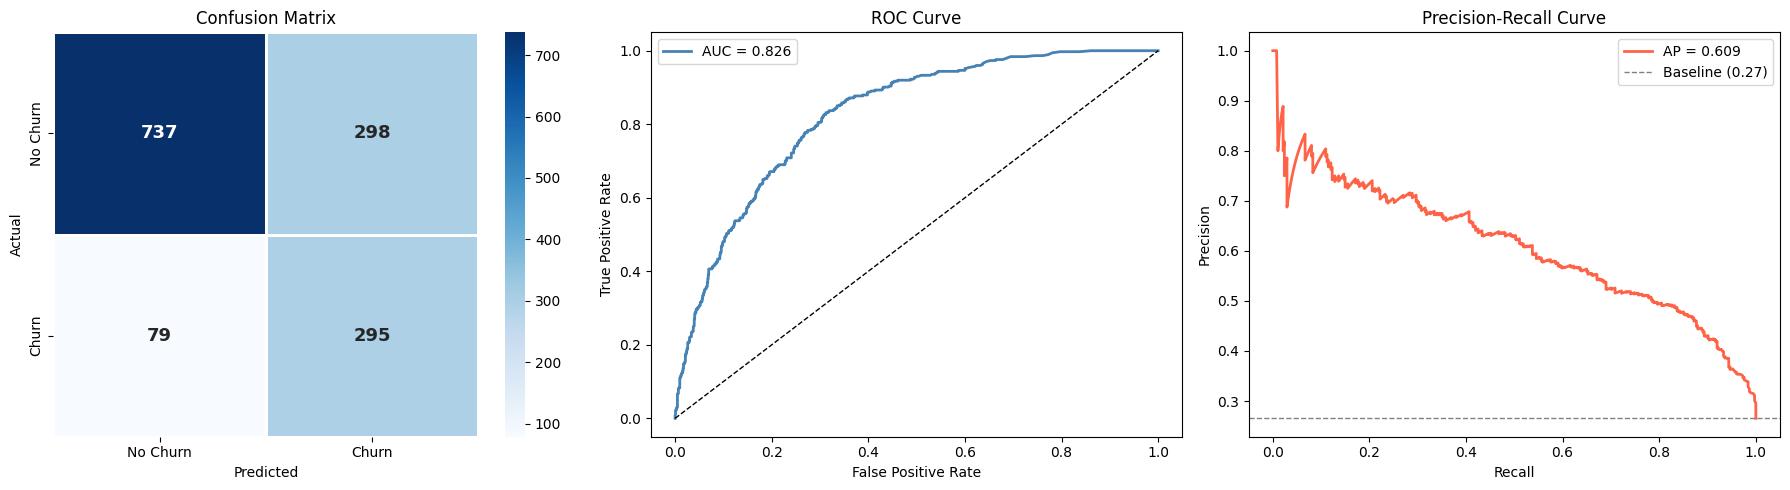

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            linewidths=1, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'},
            ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_tuned)
auc_val = roc_auc_score(y_test, y_prob_tuned)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc_val:.3f}')
axes[1].plot([0,1],[0,1],'k--', linewidth=1)
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_prob_tuned)
ap = average_precision_score(y_test, y_prob_tuned)
axes[2].plot(rec, prec, color='tomato', linewidth=2, label=f'AP = {ap:.3f}')
axes[2].axhline(y_test.mean(), color='gray', linestyle='--',
                linewidth=1, label=f'Baseline ({y_test.mean():.2f})')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.show()

<a id='9'></a>
## 9. Feature Importance

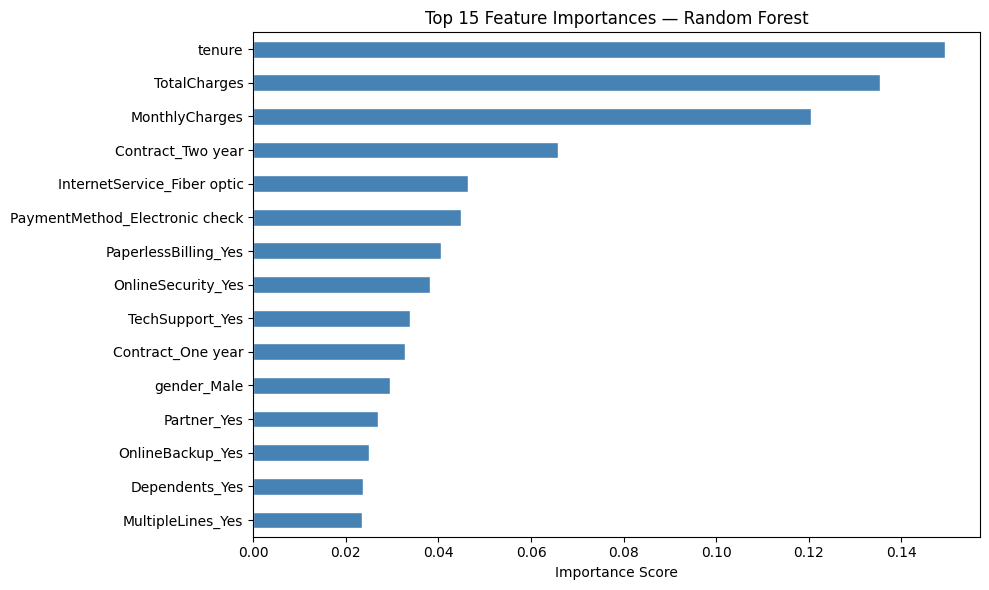

In [47]:
feat_imp = pd.Series(tuned_model.feature_importances_, 
                     index=X.columns).sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 15 Feature Importances — Random Forest', fontsize=12)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

<a id='10'></a>
## 10. Conclusion

---

### Results Summary — Cross Validation (SMOTE-balanced train set)

| Model | CV F1 (churn) | CV F1 (std) | CV ROC-AUC |
|-------|---------------|-------------|------------|
| Logistic Regression | 0.7830 | ±0.0063 | 0.8549 |
| Gradient Boosting | 0.8517 | ±0.0114 | 0.9324 |
| XGBoost | 0.8484 | ±0.0035 | 0.9297 |
| **Random Forest — Final Model** | **0.8567** | **±0.0061** | **0.9256** |

### Final Test Performance (real distribution, threshold = 0.33)

| Metric | No Churn | Churn |
|--------|----------|-------|
| Precision | 0.90 | 0.50 |
| Recall | 0.71 | 0.79 |
| F1-Score | 0.80 | 0.61 |
| Accuracy | 0.7324 | 0.7324 |
| ROC-AUC | 0.8261 | 0.8261 |

> **Note:** CV ROC-AUC (0.9256) is higher than test ROC-AUC (0.8261) because SMOTE creates synthetic samples on balanced data, inflating CV scores. The test set reflects the real 26% churn distribution — this is the honest number. Always evaluate final performance on real, unbalanced test data.

### Key Findings

- **Contract type** is the strongest predictor — month-to-month customers churn at ~42%
- **Tenure** is the most powerful numerical feature — churn risk is highest in the first 12 months
- **SMOTE** was critical — without it, the model would default to predicting no churn for most cases
- **Threshold lowered from 0.50 → 0.33** — traded precision (0.50) for recall (0.79) on the churn class. Catching 79% of churners at the cost of some false positives is the right business tradeoff
- **Random Forest outperformed XGBoost and Gradient Boosting** on CV F1
- **SHAP confirms business intuition** — tenure, contract type, and monthly charges drive predictions

### Business Recommendations

- **Target early-tenure customers** (0–12 months) with onboarding and loyalty incentives
- **Promote annual/two-year contracts** — they reduce churn dramatically
- **Offer OnlineSecurity and TechSupport bundles** — customers without them churn more
- **Review fiber optic pricing** — high monthly charges correlate with higher churn

### Note on False Negatives

A false negative (predicting *no churn* for a customer who leaves) is more costly than a false positive (offering a retention deal to a loyal customer). The threshold was tuned to 0.33 to prioritize recall, but in production the threshold should be set based on the actual cost ratio of false negatives vs false positives.

---

*If you found this notebook helpful, please upvote!*
*Muhammad Ali Ejaz — [Kaggle](https://www.kaggle.com/chaliejaz) | [LinkedIn](https://linkedin.com/in/muhammad-ali-ejaz-855117341)*